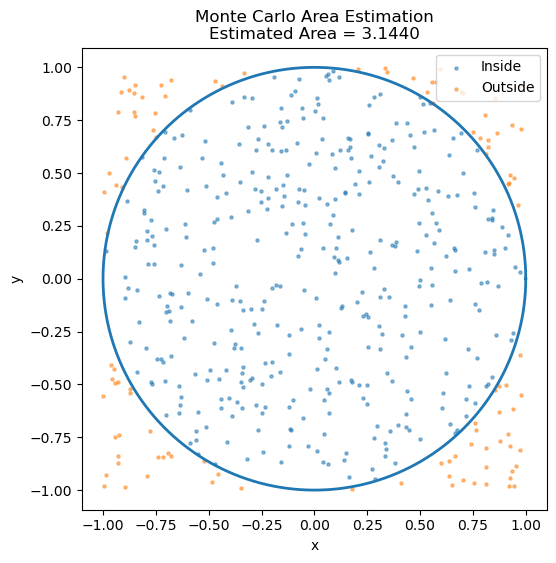

Estimated Area: 3.1440


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Number of random points
N = 500

# Define the irregular shape: inside a circle (example)
def is_inside(x, y):
    return x**2 + y**2 <= 1   # Circle of radius 1

# Generate random points in bounding box [-1,1] x [-1,1]
x_random = np.random.uniform(-1, 1, N)
y_random = np.random.uniform(-1, 1, N)

# Check points inside shape
inside_x = []
inside_y = []
outside_x = []
outside_y = []

for x, y in zip(x_random, y_random):
    if is_inside(x, y):
        inside_x.append(x)
        inside_y.append(y)
    else:
        outside_x.append(x)
        outside_y.append(y)

# Estimate area
area_box = 4   # (-1 to 1) * (-1 to 1)
area_estimate = area_box * len(inside_x) / N

# Plot
plt.figure(figsize=(6,6))

# Plot inside points
plt.scatter(inside_x, inside_y, s=5, alpha=0.5, label="Inside")

# Plot outside points
plt.scatter(outside_x, outside_y, s=5, alpha=0.5, label="Outside")

# Draw circle boundary
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), linewidth=2)

plt.title(f"Monte Carlo Area Estimation\nEstimated Area = {area_estimate:.4f}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axis("equal")

plt.show()

# Print result
print(f"Estimated Area: {area_estimate:.4f}")

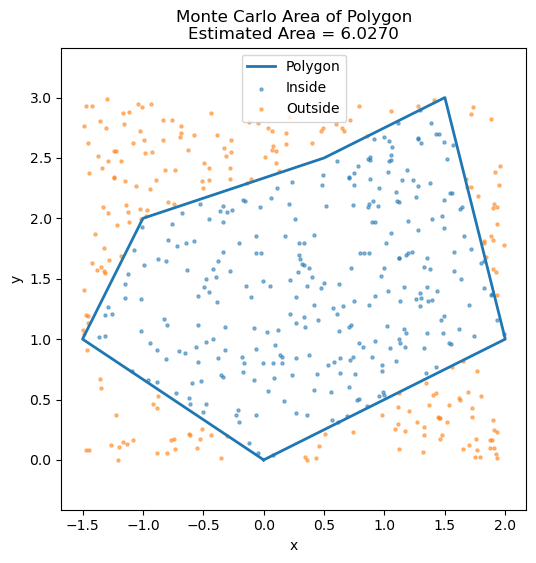

Estimated Area: 6.0270


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path

# Number of random points
N = 500

# Define polygon vertices (example: irregular polygon)
polygon = np.array([
    [0, 0],
    [2, 1],
    [1.5, 3],
    [0.5, 2.5],
    [-1, 2],
    [-1.5, 1]
])

# Create path for polygon
poly_path = Path(polygon)

# Bounding box
x_min, y_min = np.min(polygon, axis=0)
x_max, y_max = np.max(polygon, axis=0)

# Generate random points
x_random = np.random.uniform(x_min, x_max, N)
y_random = np.random.uniform(y_min, y_max, N)
points = np.vstack((x_random, y_random)).T

# Check points inside polygon
inside = poly_path.contains_points(points)

inside_points = points[inside]
outside_points = points[~inside]

# Area estimation
area_box = (x_max - x_min) * (y_max - y_min)
area_estimate = area_box * len(inside_points) / N

# Plot
plt.figure(figsize=(6,6))

# Plot polygon
plt.plot(*zip(*(list(polygon) + [polygon[0]])), linewidth=2, label="Polygon")

# Plot points
plt.scatter(inside_points[:,0], inside_points[:,1], s=5, alpha=0.5, label="Inside")
plt.scatter(outside_points[:,0], outside_points[:,1], s=5, alpha=0.5, label="Outside")

plt.title(f"Monte Carlo Area of Polygon\nEstimated Area = {area_estimate:.4f}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axis("equal")

plt.show()

# Print result
print(f"Estimated Area: {area_estimate:.4f}")